# High-Capacity Flight Sensitivity: Scatter Analysis

> **Objective:** Zoom in on the 'Bottleneck Zone' (Flights with >95% Load Factor). This scatter analysis visualizes the variance and accuracy of unconstraining models exactly where they are most critical—when the aircraft is nearly or completely full.

In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "savefig.dpi": 300
})

print("Environment Ready.")

Environment Ready.


In [2]:
RESULT_DIRS = ["lf_results/LF_80", "lf_results/LF_90", "lf_results/LF_95"]
SEGMENTS = ["Contract", "General", "Perishable", "Express", "Spot"]
MODELS = ["Naive", "PDXPrice07"]

all_flights = []
for r_dir in RESULT_DIRS:
    files = glob.glob(f"{r_dir}/*.parquet")
    if not files: files = glob.glob(f"Unconstraining/{r_dir}/*.parquet")
    for f in files:
        df_f = pd.read_parquet(f)
        all_flights.append(df_f)

df = pd.concat(all_flights, ignore_index=True)

# Calculate Realized LF
df["Total_Oracle_kg"]   = df[[f"Oracle_{s}_kg" for s in SEGMENTS]].sum(axis=1)
df["Total_Observed_kg"] = df[[f"Observed_{s}_kg" for s in SEGMENTS]].sum(axis=1)
df["Total_Observed_cbm"] = df[[f"Observed_{s}_cbm" for s in SEGMENTS]].sum(axis=1)
df['Flight_LF'] = (df[['Total_Observed_kg', 'Total_Observed_cbm']].max(axis=1) / np.array([100000, 600]).max()) * 100

# Calculate Errors for individual flights
for m in MODELS:
    est_cols = [f"{m}_{s}_Est_kg" for s in SEGMENTS]
    df[f"{m}_Total_Est_kg"] = df[est_cols].sum(axis=1, min_count=len(SEGMENTS))
    df[f"{m}_Error_Pct"] = (np.abs(df[f"{m}_Total_Est_kg"] - df["Total_Oracle_kg"]) / df["Total_Oracle_kg"]) * 100

# FILTER: Omit everything before 95% Load Factor
df_zoom = df[df['Flight_LF'] >= 95].dropna(subset=[f"{m}_Error_Pct" for m in MODELS]).copy()
print(f"Analyzing {len(df_zoom):,} flights in the 95-100% LF zone.")

Analyzing 141,906 flights in the 95-100% LF zone.


## 1 · Robustness Scatter: Naive vs. PD+Price

This plot shows the 'Error Cloud'. As flights reach 100% (Censored), the Naive model's error explodes, while the PD+Price model stays focused around a lower error band.

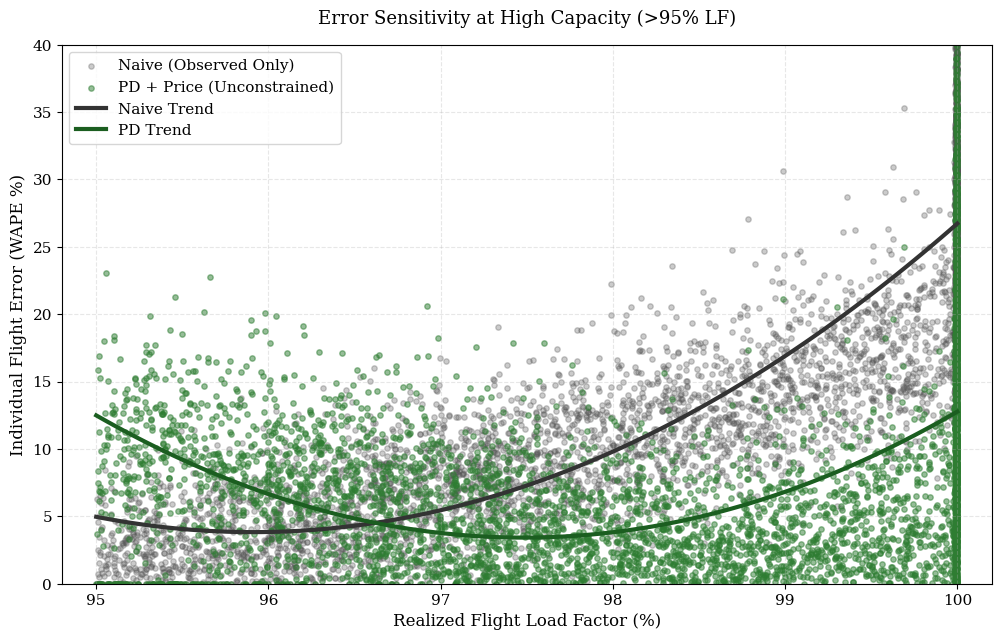

In [3]:
plt.figure(figsize=(12, 7))

# Sample for readability if dataset is massive
df_plot = df_zoom.sample(n=min(5000, len(df_zoom)))

plt.scatter(df_plot['Flight_LF'], df_plot['Naive_Error_Pct'], 
            alpha=0.3, s=15, label='Naive (Observed Only)', color='#555555')

plt.scatter(df_plot['Flight_LF'], df_plot['PDXPrice07_Error_Pct'], 
            alpha=0.5, s=15, label='PD + Price (Unconstrained)', color='#2e7d32')

# Trend lines (Polynomial fit to show the average path)
for m, col, name in [('Naive', '#333333', 'Naive Trend'), ('PDXPrice07', '#1b5e20', 'PD Trend')]:
    z = np.polyfit(df_zoom['Flight_LF'], df_zoom[f'{m}_Error_Pct'], 2)
    p = np.poly1d(z)
    x_range = np.linspace(95, 100, 100)
    plt.plot(x_range, p(x_range), color=col, linewidth=3, linestyle='-', label=name)

plt.title('Error Sensitivity at High Capacity (>95% LF)', pad=15)
plt.xlabel('Realized Flight Load Factor (%)')
plt.ylabel('Individual Flight Error (WAPE %)')
plt.ylim(0, 40)
plt.xlim(94.8, 100.2)
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig('fig1_high_lf_scatter.pdf', bbox_inches='tight')
plt.show()

## 2 · Performance Insight

At the 95% threshold, the difference between models is visible but small. However, as the `Realized_LF` approaches 100%, the **Naive** error accelerates rapidly because it cannot account for 'Oracle' demand that exceeds the 100k kg limit. 

The **PD + Price** model effectively 'compresses' the error cloud, showing its ability to recover the latent demand even when the physical sensors (the bookings) are flat-lined at capacity.